In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score , balanced_accuracy_score , classification_report
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv(r"C:\Users\alvin\OneDrive\Desktop\student_dataset_10000_rows.csv")
print(df)

      study_hours  attendance  sleep_hours  internet_usage  \
0               7          56            8               7   
1               4          69            5               3   
2              11          60            7               6   
3               8          99            9               8   
4               5          52            8               6   
...           ...         ...          ...             ...   
9995            2          58            9               7   
9996            7          98            6               9   
9997           10          44            8               5   
9998           10          75            7               5   
9999            2          70            6              11   

      assignments_completed  previous_score  exam_score placement_status  
0                        10              62      100.00           Placed  
1                         8              56      100.00           Placed  
2                        10   

In [3]:
print(df.shape)

(10000, 8)


In [4]:
le = LabelEncoder()
df['placement_encoded'] = le.fit_transform(df['placement_status'])

In [5]:
print(df.columns)

Index(['study_hours', 'attendance', 'sleep_hours', 'internet_usage',
       'assignments_completed', 'previous_score', 'exam_score',
       'placement_status', 'placement_encoded'],
      dtype='str')


In [6]:
X = df[['study_hours' , 'attendance' , 'sleep_hours' , 'internet_usage' , 'assignments_completed' , 'previous_score']]
y = df['placement_encoded']
print("\nInput X: ")
print(X)
print("\nInput y: ")
print(y)


Input X: 
      study_hours  attendance  sleep_hours  internet_usage  \
0               7          56            8               7   
1               4          69            5               3   
2              11          60            7               6   
3               8          99            9               8   
4               5          52            8               6   
...           ...         ...          ...             ...   
9995            2          58            9               7   
9996            7          98            6               9   
9997           10          44            8               5   
9998           10          75            7               5   
9999            2          70            6              11   

      assignments_completed  previous_score  
0                        10              62  
1                         8              56  
2                        10              45  
3                         4              55  
4             

In [7]:
print(X.shape)
print(y.shape)

(10000, 6)
(10000,)


In [8]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2 , random_state=42)
print(f"Training rows: {len(X_train)}")
print(f"Testing rows: {len(X_test)}")

Training rows: 8000
Testing rows: 2000


In [9]:
model = DecisionTreeClassifier(max_depth=10 , criterion='gini' , min_samples_leaf=5 ,  min_samples_split=10 , class_weight='balanced' , random_state=42)
model.fit(X_train , y_train)
print("Model trained successfully!")

Model trained successfully!


In [10]:
predictions = model.predict(X_test)
print(f"Prediction: {predictions}")
print(f"Actual: {y_test.values}")

Prediction: [1 1 1 ... 1 1 0]
Actual: [1 1 1 ... 1 1 0]


In [11]:
accuracy = accuracy_score(y_test , predictions)
balanced = balanced_accuracy_score(y_test , predictions)
report = classification_report(y_test , predictions)
print(f"Accuracy: {accuracy:.2f}")
print(f"Balanced: {balanced:.2f}")
print(report)

Accuracy: 0.81
Balanced: 0.80
              precision    recall  f1-score   support

           0       0.48      0.77      0.59       345
           1       0.95      0.82      0.88      1655

    accuracy                           0.81      2000
   macro avg       0.71      0.80      0.73      2000
weighted avg       0.86      0.81      0.83      2000



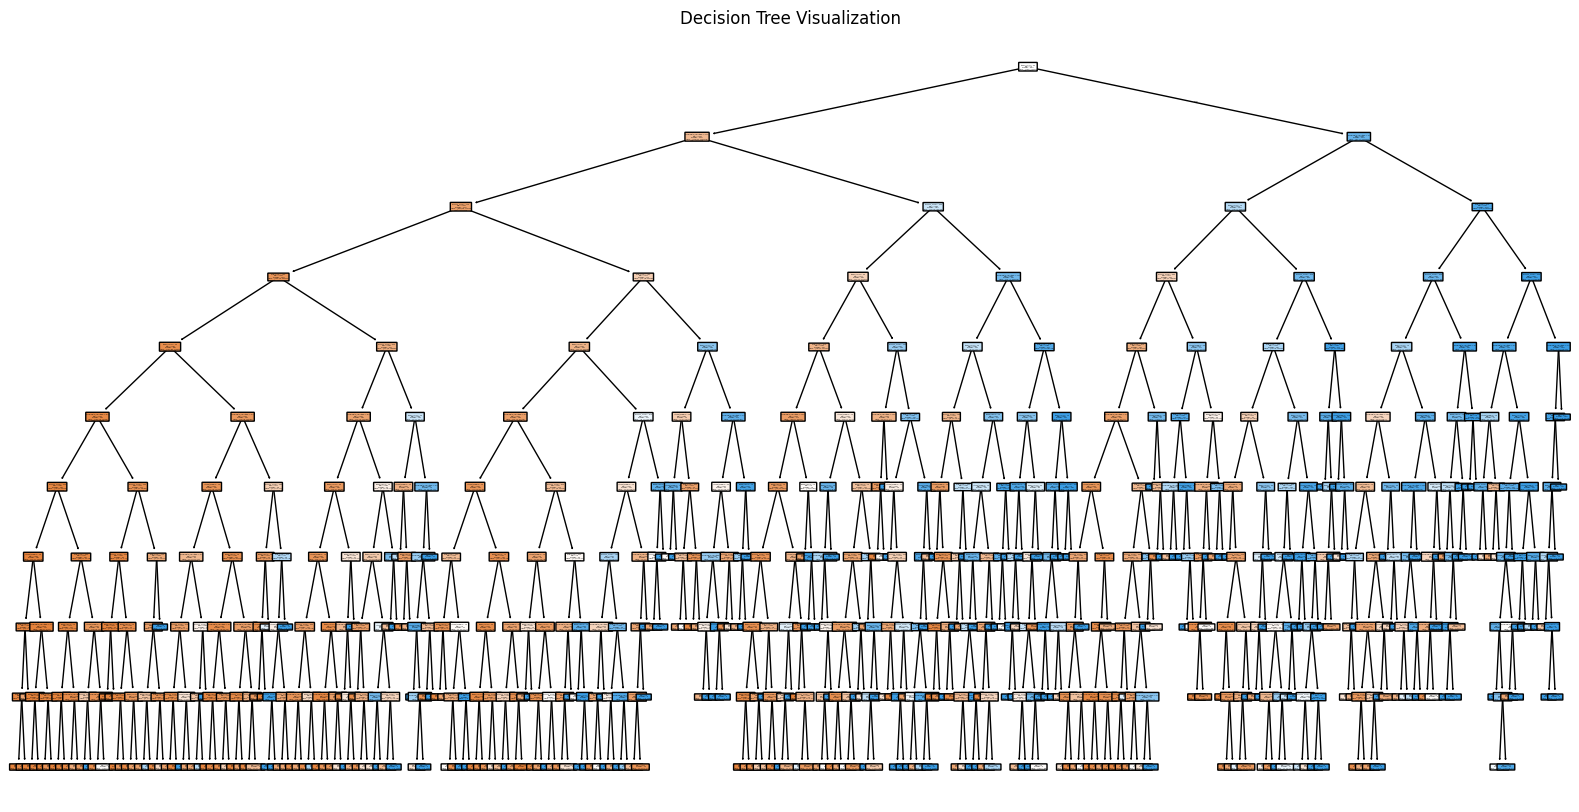

In [13]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plot_tree(
    model,
    feature_names=['study_hours', 'attendance', 
                   'sleep_hours', 'internet_usage',
                   'assignments_completed', 'previous_score'],
    class_names=['Not Placed', 'Placed'],
    filled=True,
    rounded=True
)
plt.title('Decision Tree Visualization')
plt.show()